# optimizers overview


https://arxiv.org/pdf/1609.04747

In [2]:
import jax
import jax.numpy as jnp
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
iris = sns.load_dataset("iris")

In [3]:
def loss_fn(theta):
	x, y = theta[0], theta[1]
	return 0.2 * (x - 2.0) ** 2 + 0.1 * (y + 1.0) ** 2 + 0.3 * torch.sin(3.0 * x) * torch.cos(2.0 * y)

### batch gradient descent
vanilla gradient descent

$\theta = \theta - \eta \nabla_\theta J(\theta)$

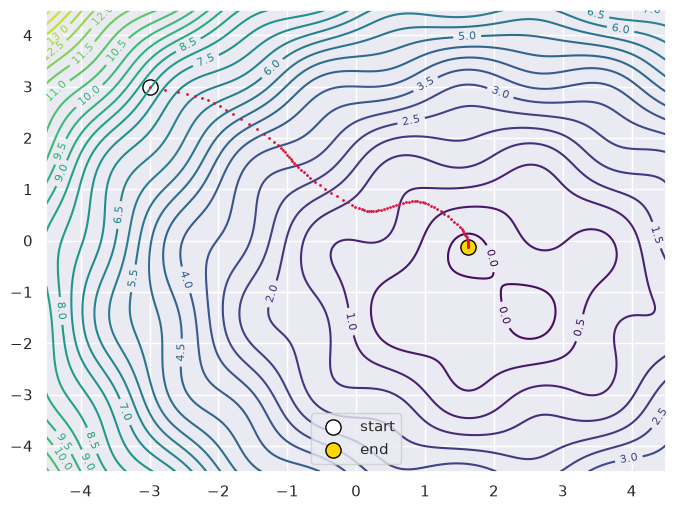

In [5]:
# Batch gradient descent
theta = torch.tensor([-3.0, 3.0], dtype=torch.float32, requires_grad=True)
lr = 0.08
steps = 100

path = [theta.detach().clone().numpy()]
for _ in range(steps):
	loss = loss_fn(theta)
	loss.backward()
	with torch.no_grad():
		theta -= lr * theta.grad
	path.append(theta.detach().clone().numpy())
	theta.grad.zero_()

path = np.array(path)

# Contour grid
x = np.linspace(-4.5, 4.5, 300)
y = np.linspace(-4.5, 4.5, 300)
X, Y = np.meshgrid(x, y)
Z = 0.2 * (X - 2.0) ** 2 + 0.2 * (Y + 1.0) ** 2 + 0.3 * np.sin(3.0 * X) * np.cos(2.0 * Y)

plt.figure(figsize=(8, 6))
cs = plt.contour(X, Y, Z, levels=30, cmap="viridis")
plt.clabel(cs, inline=True, fontsize=8, fmt="%.1f")
plt.plot(path[:, 0], path[:, 1], "o", color="crimson", linewidth=2, markersize=1)
plt.scatter(path[0, 0], path[0, 1], color="white", edgecolor="black", s=120, label="start")
plt.scatter(path[-1, 0], path[-1, 1], color="gold", edgecolor="black", s=120, label="end")
plt.legend()
plt.show()

### Stochastic Gradient Descent (SGD)
$\theta = \theta - \eta \nabla_\theta J(\theta; x^{(i)}; y^{(i)})$

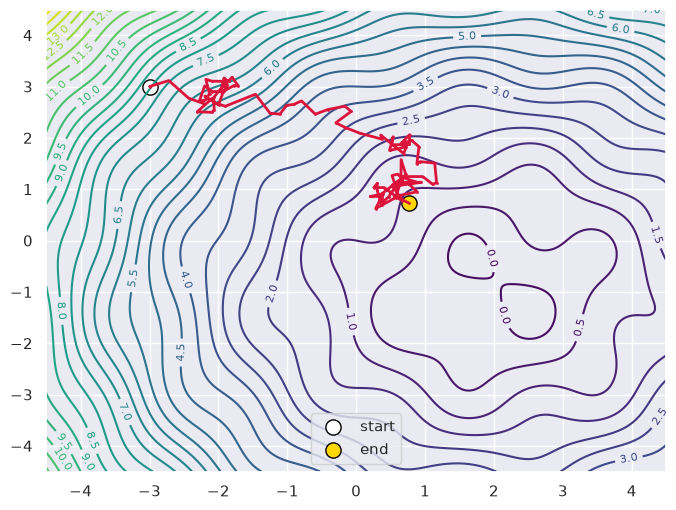

In [24]:
# Stochastic gradient descent
theta = torch.tensor([-3.0, 3.0], dtype=torch.float32, requires_grad=True)
lr = 0.08
steps = 100
noise_scale = 2.0 # Standard deviation of the noise

path = [theta.detach().clone().numpy()]
for _ in range(steps):
	loss = loss_fn(theta)
	loss.backward()
	with torch.no_grad():
		noisy_grad = theta.grad + noise_scale * torch.randn_like(theta) # aka gradient + noise
		theta -= lr * noisy_grad
	path.append(theta.detach().clone().numpy())
	theta.grad.zero_()

path = np.array(path)

plt.figure(figsize=(8, 6))
cs = plt.contour(X, Y, Z, levels=30, cmap="viridis")
plt.clabel(cs, inline=True, fontsize=8, fmt="%.1f")
plt.plot(path[:, 0], path[:, 1], "-o", color="crimson", linewidth=2, markersize=1)
plt.scatter(path[0, 0], path[0, 1], color="white", edgecolor="black", s=120, label="start")
plt.scatter(path[-1, 0], path[-1, 1], color="gold", edgecolor="black", s=120, label="end")
plt.legend()
plt.show()

### mini-batch gradient descent

different inputs. assumed same weights $\theta$ averaged.

### Momentum
page out of newtonian physics

$v_t = \gamma \cdot v_{t-1} + \eta \cdot \nabla_\theta J(\theta)$

$\theta = \theta - v_t$

### Nesterov accelerated gradient


### Adagrad

### Adadelta

### RMSprop
read rmsprop.ipynb

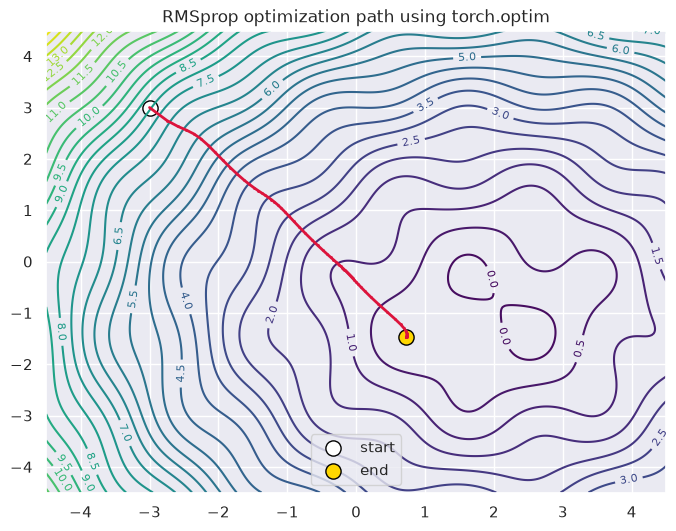

In [8]:
# RMSprop using torch.optim
theta = torch.tensor([-3.0, 3.0], dtype=torch.float32, requires_grad=True)
lr = 0.08
steps = 100
rho = 0.9
eps = 1e-8

optimizer = torch.optim.RMSprop([theta], lr=lr, alpha=rho, eps=eps)

path = [theta.detach().clone().numpy()]
for _ in range(steps):
	optimizer.zero_grad()
	loss = loss_fn(theta)
	loss.backward()
	optimizer.step()

	path.append(theta.detach().clone().numpy())

path = np.array(path)

plt.figure(figsize=(8, 6))
cs = plt.contour(X, Y, Z, levels=30, cmap="viridis")
plt.clabel(cs, inline=True, fontsize=8, fmt="%.1f")
plt.plot(path[:, 0], path[:, 1], "-o", color="crimson", linewidth=2, markersize=1)
plt.scatter(path[0, 0], path[0, 1], color="white", edgecolor="black", s=120, label="start")
plt.scatter(path[-1, 0], path[-1, 1], color="gold", edgecolor="black", s=120, label="end")
plt.title("RMSprop optimization path using torch.optim")
plt.legend()
plt.show()


### Adam
read adam.ipynb

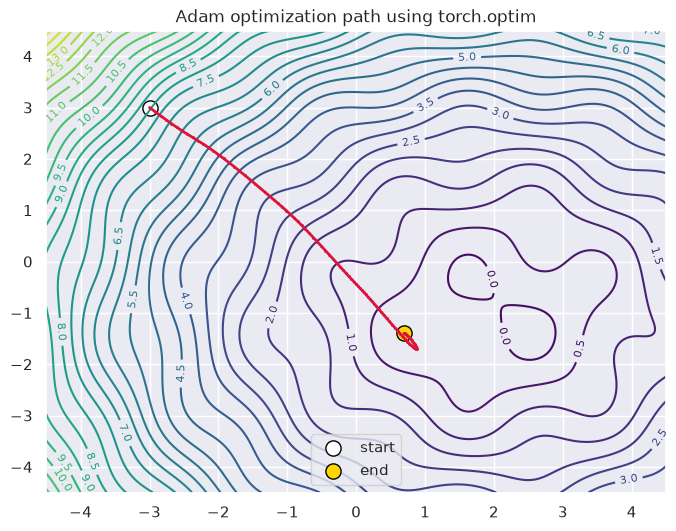

In [9]:
# Adam using torch.optim
theta = torch.tensor([-3.0, 3.0], dtype=torch.float32, requires_grad=True)
lr = 0.08
steps = 100
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

optimizer = torch.optim.Adam([theta], lr=lr, betas=(beta1, beta2), eps=eps)

path = [theta.detach().clone().numpy()]
for _ in range(steps):
	optimizer.zero_grad()
	loss = loss_fn(theta)
	loss.backward()
	optimizer.step()

	path.append(theta.detach().clone().numpy())

path = np.array(path)

plt.figure(figsize=(8, 6))
cs = plt.contour(X, Y, Z, levels=30, cmap="viridis")
plt.clabel(cs, inline=True, fontsize=8, fmt="%.1f")
plt.plot(path[:, 0], path[:, 1], "-o", color="crimson", linewidth=2, markersize=1)
plt.scatter(path[0, 0], path[0, 1], color="white", edgecolor="black", s=120, label="start")
plt.scatter(path[-1, 0], path[-1, 1], color="gold", edgecolor="black", s=120, label="end")
plt.title("Adam optimization path using torch.optim")
plt.legend()
plt.show()

### AdaMax

### Nadam

### AdamW